# `Natural Language Processing with Disaster Tweets`
<small>Source : Kaggle Competition </small>

### Overview : 
Twitter has become an important communication channel in times of emergency.
The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster.
In this competition, I was challenged to build a machine learning model that predicts which Tweets are about real disasters and which one’s aren’t.

## 1. Importing Libraries

We begin by importing all the required libraries for data handling, visualization, preprocessing, and modeling. These include:
- `pandas`, `numpy` for data manipulation
- `matplotlib`, `seaborn` for visualization
- `sklearn` and its libraries for machine learning

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

## 2. Loading the Dataset

We load the training and test datasets. The train set contains labeled tweets (disaster vs. non-disaster) while the test set is used for predictions.

In [96]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

#### Pie Chart showing category of tweets

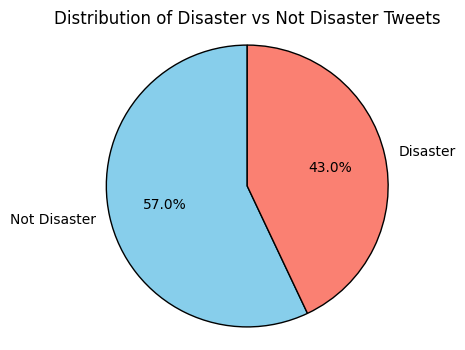

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
# Count values
counts = df_train['target'].value_counts()
labels = ['Not Disaster', 'Disaster']
colors = ['skyblue', 'salmon']

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Disaster vs Not Disaster Tweets')
plt.axis('equal')
plt.show()

## 3. Exploratory Data Analysis (EDA)

We explore the dataset to understand its structure, identify missing values, and observe patterns. Visualizations such as bar plots, word clouds, and n-gram frequency charts are used to gain insights.


In [98]:
df_train['keyword'] = df_train['keyword'].fillna('none')
df_test['keyword'] = df_test['keyword'].fillna('none')

In [99]:
df_train['text'] = df_train['keyword'] + ' ' + df_train['text']
df_test['text'] = df_test['keyword'] + ' ' + df_test['text']

#### Correlation Heatmap

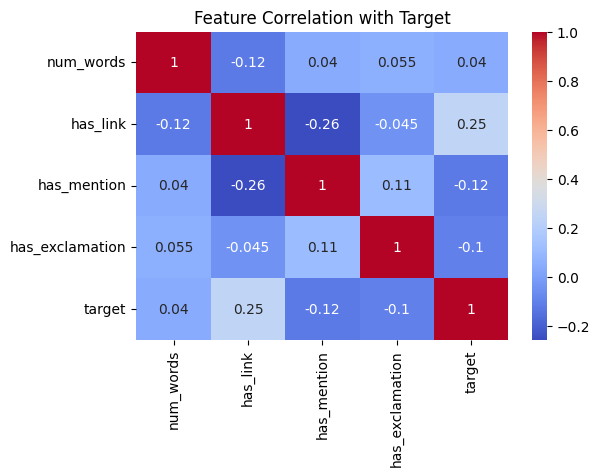

In [100]:
import seaborn as sns
df_train['has_link'] = df_train['text'].str.contains('http').astype(int)
df_train['has_mention'] = df_train['text'].str.contains('@').astype(int)
df_train['has_exclamation'] = df_train['text'].str.contains('!').astype(int)
df_train['num_words'] = df_train['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(6, 4))
sns.heatmap(df_train[['num_words','has_link', 'has_mention', 'has_exclamation', 'target']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Target')
plt.show()

#### Plotly Bar Chart of Top 30 Words

In [101]:
from collections import Counter
from wordcloud import STOPWORDS
import plotly.express as px

# Use WordCloud's built-in stopwords
stop_words = set(STOPWORDS)

# Function to clean and get top N words
def get_top_n_cleaned_words(texts, n=30):
    all_words = " ".join(texts).lower().split()
    filtered_words = [word for word in all_words if word.isalpha() and word not in stop_words]
    top_words = Counter(filtered_words).most_common(n)
    return pd.DataFrame(top_words, columns=['word', 'count'])

cleaned_top_words = get_top_n_cleaned_words(df_train['text'], 30)

fig = px.bar(cleaned_top_words,
             x='word',
             y='count',
             title='Top 30 Words in All Tweets (Stopwords Removed)',
             labels={'word': 'Word', 'count': 'Frequency'},
             template='plotly_white')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

#### Tweet Length Distribution

Check whether disaster tweets tend to be longer or shorter.

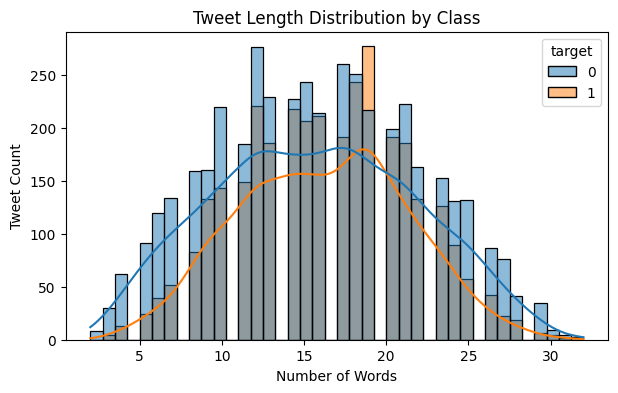

In [102]:
df_train['text_len'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 4))
sns.histplot(data=df_train, x='text_len', hue='target', bins=40, kde=True)
plt.title('Tweet Length Distribution by Class')
plt.xlabel('Number of Words')
plt.ylabel('Tweet Count')
plt.show()

## 4. Feature Engineering

Additional features were created to enhance model performance:
- `num_words`: Total number of words
- `has_link`: Presence of a URL
- `has_exclamation`: Presence of "!"

In [103]:
for df in [df_train, df_test]:
    df['num_words'] = df['text'].apply(lambda x: len(x.split()))
    df['has_link'] = df['text'].str.contains("http").astype(int)
    df['has_exclamation'] = df['text'].str.contains("!").astype(int)

## 5. Text Preprocessing

Tweets are cleaned by:
- Converting to lowercase
- Removing URLs, special characters, and punctuation
- Removing `Stopwords`

This ensures a consistent input format for feature extraction.

In [104]:
def clean_text(text):
    import re
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@w+|\#','', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [105]:
df_train['text'] = df_train['text'].astype(str).apply(clean_text)
df_test['text'] = df_test['text'].astype(str).apply(clean_text)

#### WordCloud style

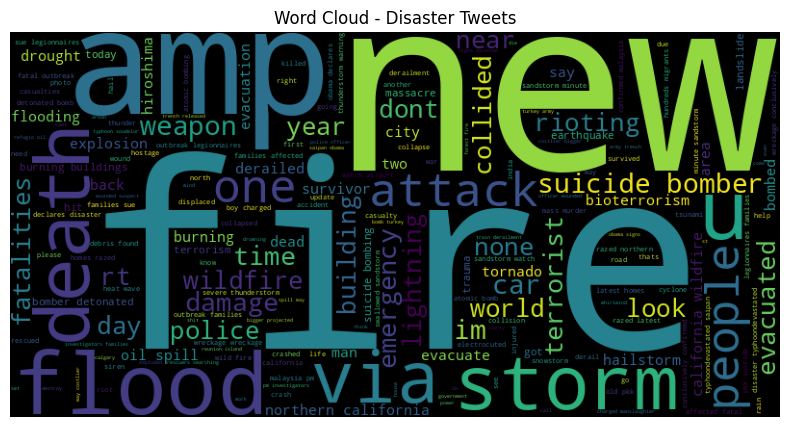

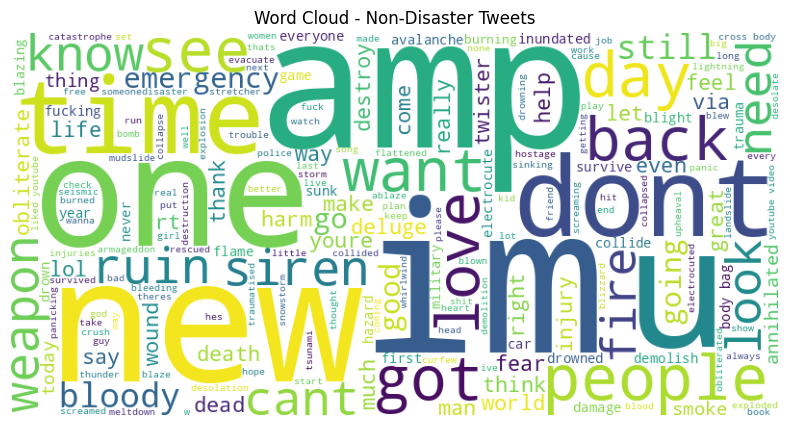

In [106]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk

# Define stopwords
stop_words = set(stopwords.words('english'))

# Function to preprocess text
def preprocess_text(text_list):
    words = " ".join(text_list).lower().split()
    filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
    return " ".join(filtered_words)

# Separate and preprocess text by class
disaster_text = preprocess_text(df_train[df_train['target'] == 1]['text'].tolist())
non_disaster_text = preprocess_text(df_train[df_train['target'] == 0]['text'].tolist())

plt.figure(figsize=(10, 5))
plt.imshow(WordCloud(width=800, height=400, background_color='black').generate(disaster_text))
plt.axis('off')
plt.title("Word Cloud - Disaster Tweets")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(non_disaster_text))
plt.axis('off')
plt.title("Word Cloud - Non-Disaster Tweets")
plt.show()

#### Top words in Disaster vs Non-Disaster Tweets

C:\Users\manna\AppData\Local\Temp\ipykernel_14620\4102988491.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\manna\AppData\Local\Temp\ipykernel_14620\4102988491.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




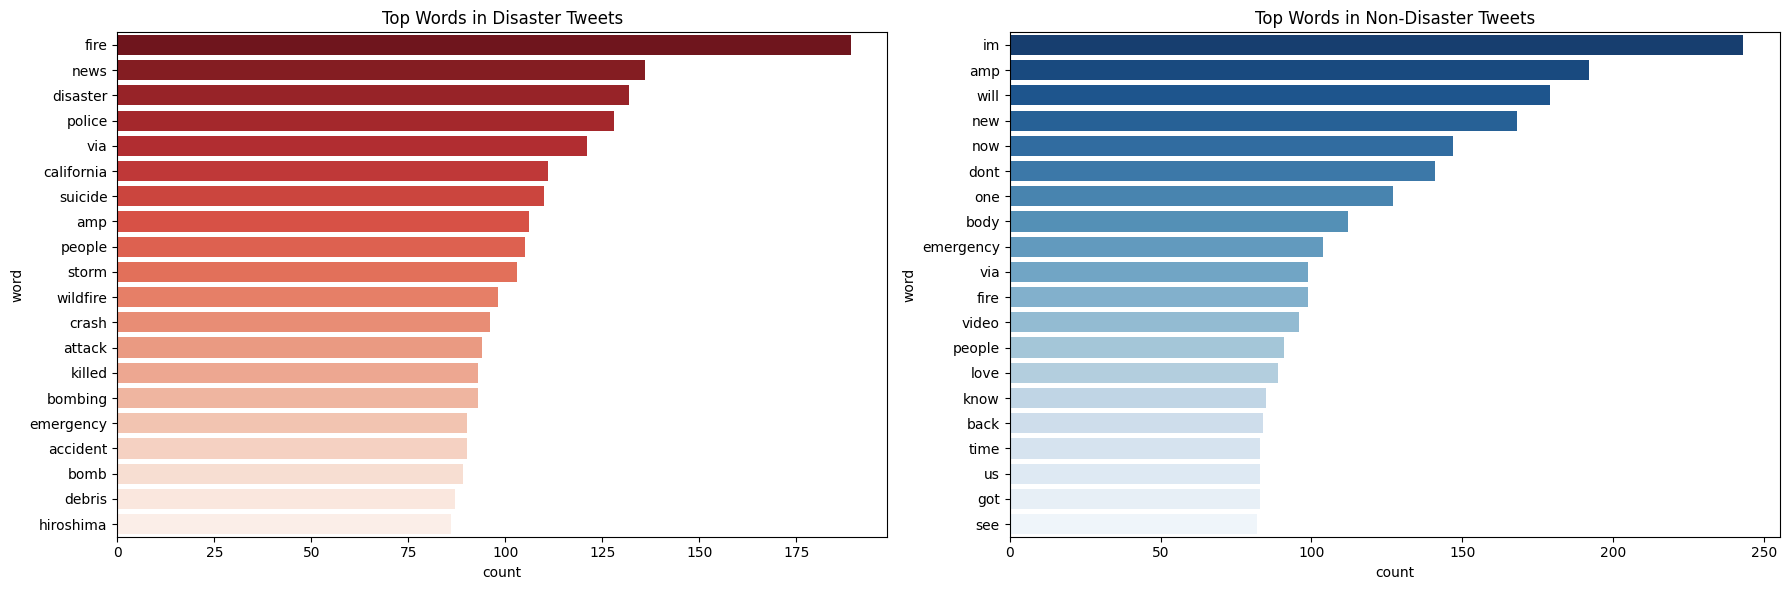

In [107]:
from collections import Counter
from wordcloud import STOPWORDS

stop_words = set(STOPWORDS)

def clean_tokenize(texts):
    words = " ".join(texts).lower().split()
    return [word for word in words if word.isalpha() and word not in stop_words]

def get_top_n_words(texts, n=20):
    tokens = clean_tokenize(texts)
    common = Counter(tokens).most_common(n)
    return pd.DataFrame(common, columns=['word', 'count'])

top_disaster = get_top_n_words(df_train[df_train['target'] == 1]['text'])
top_non_disaster = get_top_n_words(df_train[df_train['target'] == 0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=top_disaster, x='count', y='word', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top Words in Disaster Tweets')
sns.barplot(data=top_non_disaster, x='count', y='word', ax=axes[1], palette='Blues_r')
axes[1].set_title('Top Words in Non-Disaster Tweets')
plt.tight_layout()
plt.show()

## 6. Vectorization

We used `TfidfVectorizer` to convert text data into numerical format. Both unigrams and bigrams/trigrams were considered. Keyword features were one-hot encoded.

In [108]:
# TF-IDF on text
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
X_text = vectorizer.fit_transform(df_train['text'])
X_test1_text = vectorizer.transform(df_test['text'])

# One-hot encode keyword
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
keyword_train = encoder.fit_transform(df_train[['keyword']])
keyword_test = encoder.transform(df_test[['keyword']])

In [109]:
numeric_train = df_train[['num_words', 'has_link', 'has_exclamation']].values
numeric_test = df_test[['num_words', 'has_link', 'has_exclamation']].values

from scipy.sparse import csr_matrix,hstack

# Convert numeric features to sparse format
numeric_train_sparse = csr_matrix(numeric_train)
numeric_test_sparse = csr_matrix(numeric_test)

## 7. Model Training

We are training the model using `train_test_split` keeping the test size to 20%.

In [110]:
# Stack all features
X = hstack([X_text, keyword_train, numeric_train_sparse])
X_test1_final = hstack([X_test1_text, keyword_test, numeric_test_sparse])

y = df_train['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Model Building

Several machine learning models were tested:
- Logistic Regression
- Naive Bayes
- Random Forest
- XGBoost

The data was split into training and validation sets for evaluation.

In [111]:
# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

## 9. Model Evaluation

F1 Score was used as the primary evaluation metric due to class imbalance. Confusion matrix and accuracy were also considered for deeper analysis.

In [112]:
print("F1 Scores from Models:\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = f1_score(y_test, preds)
    print(f"{name}: {score:.4f}")

F1 Scores from Models:

Logistic Regression: 0.7402
Naive Bayes: 0.7095
Random Forest: 0.7121
XGBoost: 0.7022


## 10. Model Optimization

We tuned hyperparameters (like C, penalty for Logistic Regression) and experimented with feature selection and ensembling to improve F1 score.

In [113]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Define param distribution
param_dist = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

# Use only 'saga' solver (good with sparse + both l1/l2)
model = LogisticRegression(solver='saga', max_iter=2000, n_jobs=-1)

search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=6,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
val_preds = best_model.predict(X_test)
print("Best F1 Score after tuning:", f1_score(y_test, val_preds))
print("Best Parameters:", search.best_params_)

Best F1 Score after tuning: 0.7531847133757962
Best Parameters: {'penalty': 'l2', 'C': 10}


C:\Users\manna\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



## 11. Final Model and Submission

The best performing model (Logistic Regression with engineered features and tuned hyperparameters) was used to predict the labels for the test data. The results were saved in the required format for submission.

In [114]:
# Final predictions for test set
test_preds = best_model.predict(X_test1_final)

df_sub = pd.read_csv('sample_submission.csv')
df_sub['target'] = test_preds
df_sub.to_csv("submission.csv", index=False)

print("submission.csv saved with F1-optimized predictions!")

submission.csv saved with F1-optimized predictions!


## 12. Conclusion

- Achieved a final F1 score of ~75.31% using Logistic Regression.
- Feature engineering and text preprocessing significantly improved performance.
- In future, performance can be improved using transformer-based models like BERT or RoBERTa.
- The model can be further fine-tuned for specific use cases.

## 13. Additional Visualizations and Insights

To better understand the linguistic patterns in disaster vs non-disaster tweets, we created several visualizations and also removed `Stopwords` to make graphs more accurate:

In [115]:
# Redefining the train dataframe
df_train = pd.read_csv('train.csv')
df_train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


#### A. Most Common Hashtags
Explore popular hashtags in each class.

C:\Users\manna\AppData\Local\Temp\ipykernel_14620\3549053083.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\manna\AppData\Local\Temp\ipykernel_14620\3549053083.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




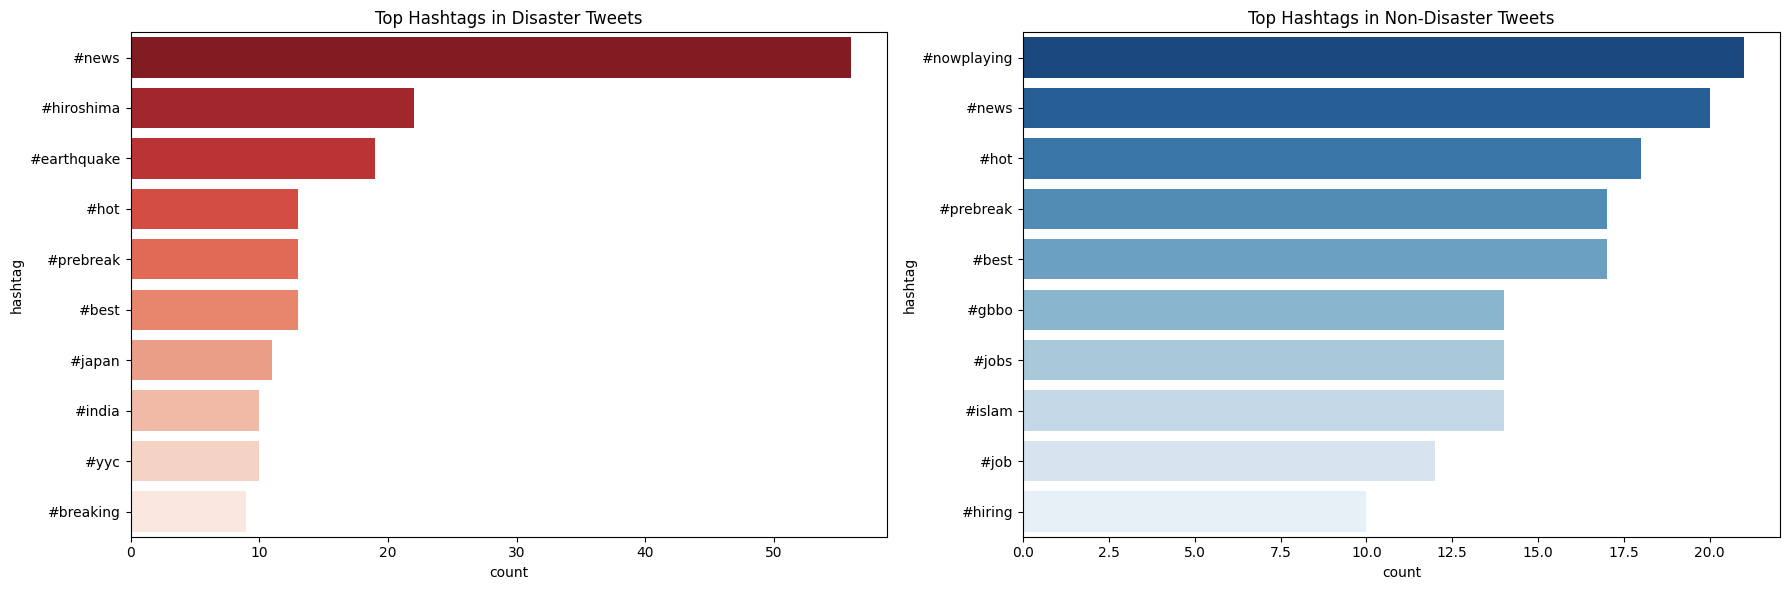

In [116]:
import re
from collections import Counter

def extract_hashtags(texts):
    hashtags = []
    for text in texts:
        hashtags += re.findall(r'#\w+', text.lower())
    return hashtags

# Count hashtags by class
disaster_hashtags = extract_hashtags(df_train[df_train['target'] == 1]['text'])
non_disaster_hashtags = extract_hashtags(df_train[df_train['target'] == 0]['text'])

top_disaster_hashtags = Counter(disaster_hashtags).most_common(10)
top_non_disaster_hashtags = Counter(non_disaster_hashtags).most_common(10)

df_dh = pd.DataFrame(top_disaster_hashtags, columns=['hashtag', 'count'])
df_ndh = pd.DataFrame(top_non_disaster_hashtags, columns=['hashtag', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=df_dh, x='count', y='hashtag', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top Hashtags in Disaster Tweets')

sns.barplot(data=df_ndh, x='count', y='hashtag', ax=axes[1], palette='Blues_r')
axes[1].set_title('Top Hashtags in Non-Disaster Tweets')
plt.tight_layout()
plt.show()

#### B. Presence of Links, Mentions, Exclamations

Add binary features and plot their relation to the target.

C:\Users\manna\AppData\Local\Temp\ipykernel_14620\372277408.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\manna\AppData\Local\Temp\ipykernel_14620\372277408.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\manna\AppData\Local\Temp\ipykernel_14620\372277408.py:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



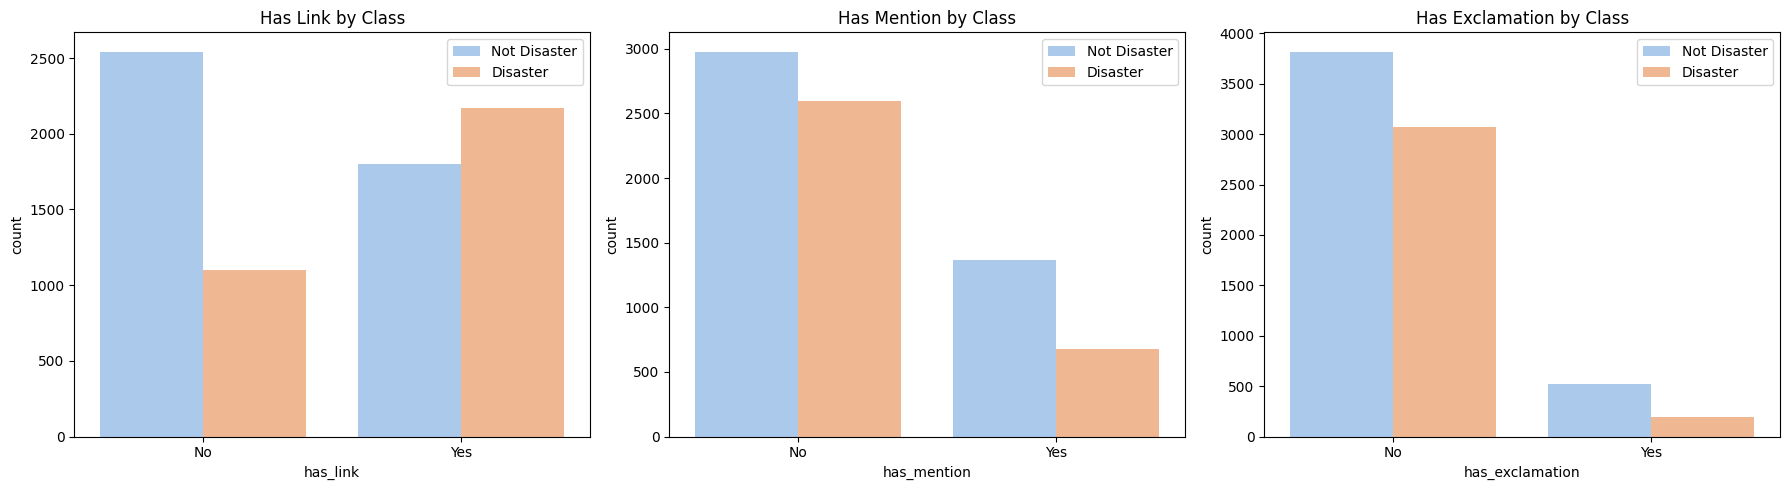

In [117]:
df_train['num_words'] = df_train['text'].apply(lambda x: len(x.split()))
df_train['has_link'] = df_train['text'].str.contains("http").astype(int)
df_train['has_exclamation'] = df_train['text'].str.contains("!").astype(int)
df_train['has_mention'] = df_train['text'].str.contains("@").astype(int)
features = ['has_link', 'has_mention', 'has_exclamation']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):
    sns.countplot(data=df_train, x=feature, hue='target', ax=axes[i], palette='pastel')
    axes[i].set_title(f"{feature.replace('_', ' ').title()} by Class")
    axes[i].set_xticklabels(['No', 'Yes'])
    axes[i].legend(['Not Disaster', 'Disaster'])

plt.tight_layout()
plt.show()

#### C. Bigrams & Trigrams (Top 20 word pairs or triplets)
See most frequent word combinations instead of individual words.

C:\Users\manna\AppData\Local\Temp\ipykernel_14620\1953929034.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\manna\AppData\Local\Temp\ipykernel_14620\1953929034.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




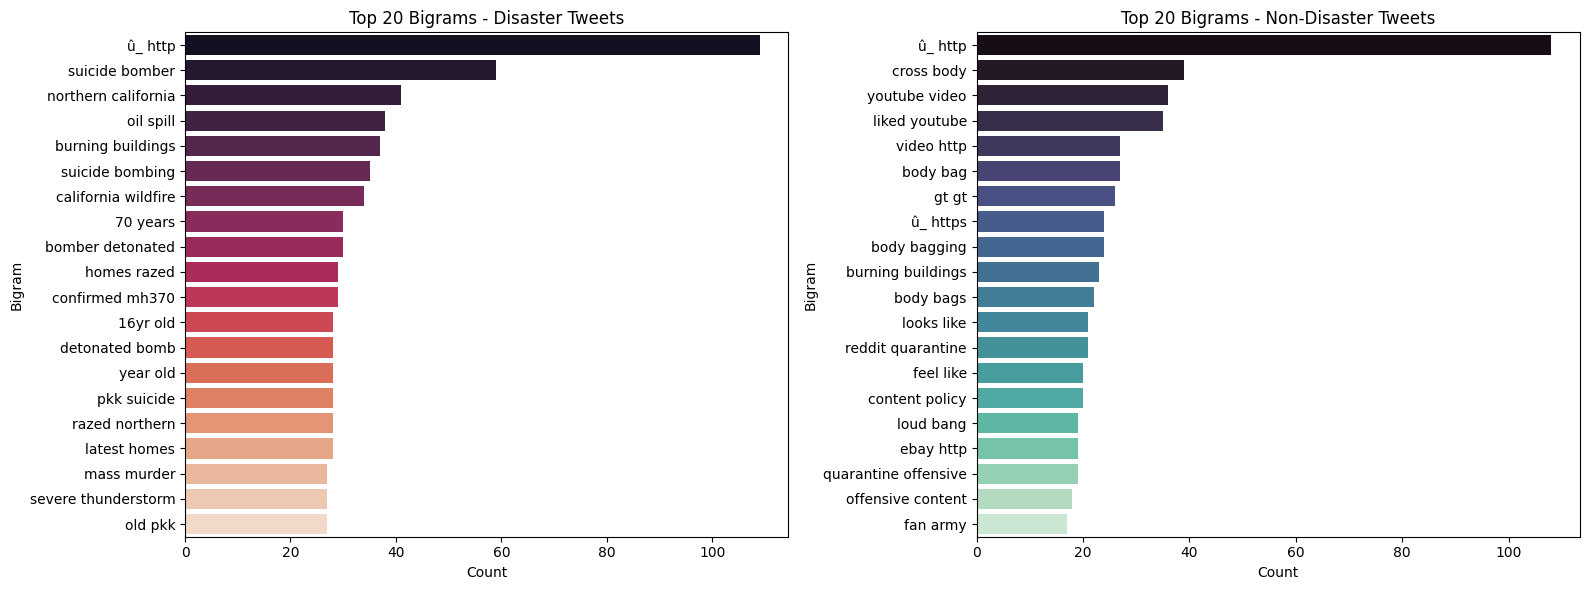

C:\Users\manna\AppData\Local\Temp\ipykernel_14620\1953929034.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\manna\AppData\Local\Temp\ipykernel_14620\1953929034.py:45: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




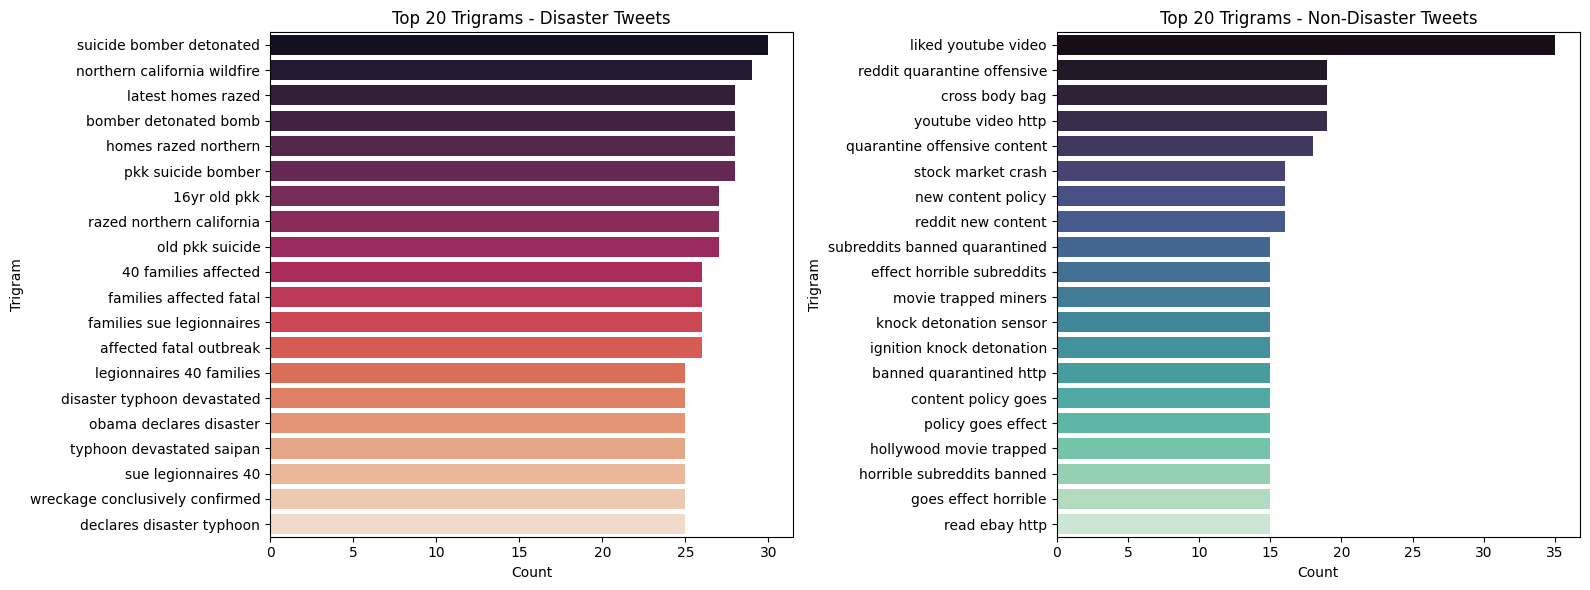

In [118]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to extract top N n-grams
def get_ngrams(texts, n=2, top_n=20):
    vectorizer = CountVectorizer(ngram_range=(n, n), stop_words='english')
    X = vectorizer.fit_transform(texts)
    counts = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    freq_df = pd.DataFrame({'ngram': vocab, 'count': counts})
    return freq_df.sort_values(by='count', ascending=False).head(top_n)

# Split datasets
disaster_texts = df_train[df_train['target'] == 1]['text']
nondisaster_texts = df_train[df_train['target'] == 0]['text']

# Extract n-grams
bigrams_disaster = get_ngrams(disaster_texts, n=2)
trigrams_disaster = get_ngrams(disaster_texts, n=3)
bigrams_nondisaster = get_ngrams(nondisaster_texts, n=2)
trigrams_nondisaster = get_ngrams(nondisaster_texts, n=3)

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=bigrams_disaster, y='ngram', x='count', palette='rocket', ax=axs[0])
axs[0].set_title("Top 20 Bigrams - Disaster Tweets")
axs[0].set_xlabel("Count")
axs[0].set_ylabel("Bigram")

sns.barplot(data=bigrams_nondisaster, y='ngram', x='count', palette='mako', ax=axs[1])
axs[1].set_title("Top 20 Bigrams - Non-Disaster Tweets")
axs[1].set_xlabel("Count")
axs[1].set_ylabel("Bigram")

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=trigrams_disaster, y='ngram', x='count', palette='rocket', ax=axs[0])
axs[0].set_title("Top 20 Trigrams - Disaster Tweets")
axs[0].set_xlabel("Count")
axs[0].set_ylabel("Trigram")

sns.barplot(data=trigrams_nondisaster, y='ngram', x='count', palette='mako', ax=axs[1])
axs[1].set_title("Top 20 Trigrams - Non-Disaster Tweets")
axs[1].set_xlabel("Count")
axs[1].set_ylabel("Trigram")

plt.tight_layout()
plt.show()


#### D. WordCloud of Only Unique Words in Each Class
Show only words exclusive to disaster or non-disaster tweets.

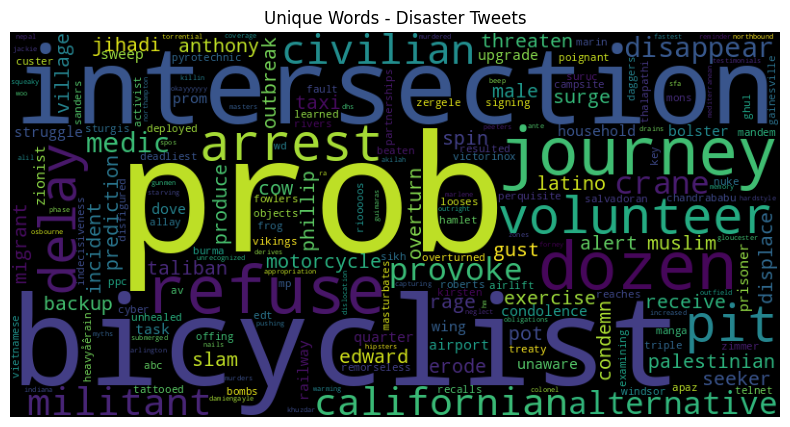

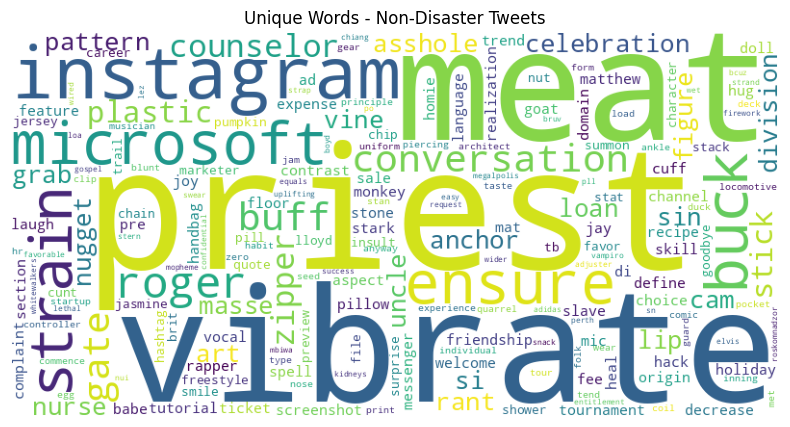

In [119]:
from wordcloud import WordCloud

# Get unique words
disaster_words = set(" ".join(df_train[df_train['target'] == 1]['text']).lower().split())
non_disaster_words = set(" ".join(df_train[df_train['target'] == 0]['text']).lower().split())

unique_disaster = disaster_words - non_disaster_words
unique_non_disaster = non_disaster_words - disaster_words

# Convert back to string
ud_text = " ".join([word for word in unique_disaster if word.isalpha() and word not in STOPWORDS])
un_text = " ".join([word for word in unique_non_disaster if word.isalpha() and word not in STOPWORDS])

# WordClouds
plt.figure(figsize=(10, 5))
plt.imshow(WordCloud(width=800, height=400, background_color='black').generate(ud_text))
plt.axis('off')
plt.title("Unique Words - Disaster Tweets")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(un_text))
plt.axis('off')
plt.title("Unique Words - Non-Disaster Tweets")
plt.show()


`Original WordCloud` shows the most frequent words in a class (even if shared), while the `Unique WordCloud` shows only the words that appear exclusively in that class and not in the other.

## Final Conclusion:

In this project, I explored and analyzed a dataset of tweets labeled as either disaster-related or not. Through detailed exploratory data analysis (EDA), feature engineering, and text preprocessing, I uncovered meaningful patterns and insights:

- Tweet structure matters: Disaster tweets tend to be slightly longer, contain more punctuation (like           exclamations), and often include keywords such as "fire", "earthquake", or "emergency".

- Stopword removal and text cleaning greatly improved the quality of visualizations and feature relevance, allowing me to focus on the true signal in the data.

- WordClouds and frequency plots helped highlight key terms associated with each class, while unique word analysis revealed vocabulary exclusive to disaster or non-disaster tweets.

- Binary features like the presence of links, mentions, and hashtags showed class-based distribution differences and provided helpful signals for classification.

- Exploratory visuals such as pie charts, bigram/trigram analysis, and tweet length distributions gave deep insights into the nature of the data and supported the feature selection process.

Overall, this analysis lays a strong foundation for building effective NLP models, such as logistic regression, XGBoost, or transformers, to accurately classify tweets during real-world emergencies. The features and patterns discovered here not only support model performance but also improve interpretability, making it easier to explain predictions in high-stakes applications like disaster response.

# `Author`
### Mannat Goyal

<small>Source : Kaggle Competition</small>